# Covariance and Correlation

**Overview**
This exercise is an introduction to correlation and covariance matrix.
The exercise will guide:
- Understanding of what **covariance** and **correlation** are.
- Implementation of both matrices using basic NumPy operations.
- Interpreting the meaning of these matrices in terms of variable relationships.


In data analysis and machine learning, understanding the relationships between variables is crucial.

Two key tools for this are the **covariance** and **correlation** matrices.
Recall the definitions: 

$$
\text{Covariance: }\newline  \text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

$$\text{ }\newline$$

$$
\text{Correlation: } \newline   \text{Corr}(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$
The cell below defines a synthetic dataset containing 4 features, the data could resemble _height_, _weight_, _age_ and _shoe size_ of a set of people. 

---
**Task 1 (medium): Reflect on theory💡📽️**
1. Explain the key characteristics of covariance and correlation. Use the following questions to guide your explanation.    - What does each one assess?
    - How do they describe relationships between variables differently?
    - Why might you prefer one measure over the other in analysis?
    - What does a covariance of zero mean? Does it imply independence?
    - Why are the diagonal elements of the covariance matrix always the variances of the variables?
    - Why are the diagonal elements of the correlation matrix always equal to 1?
    - What does the sign of a covariance or correlation value tell us?
    - Can two variables be strongly related but have a correlation close to zero? Under what circumstances?




---

## Key Characteristics of Covariance and Correlation

### What does each one assess?

**Covariance** measures the direction and magnitude of the linear relationship between two variables. It quantifies how much two variables change together - whether they tend to increase or decrease simultaneously, or if one increases while the other decreases.

**Correlation** measures the strength and direction of the linear relationship between two variables, normalized to a scale between -1 and +1. It provides a standardized measure that is independent of the units of measurement.

### How do they describe relationships between variables differently?

- **Covariance** is scale-dependent and measured in units that are the product of the units of the two variables (e.g., if X is in meters and Y is in kilograms, covariance is in meter-kilograms). The magnitude depends on the scale of the variables, making it difficult to compare covariances across different variable pairs.

- **Correlation** is scale-independent and dimensionless, always ranging from -1 to +1. This makes it easier to compare the strength of relationships across different variable pairs, regardless of their units or scales.

### Why might you prefer one measure over the other in analysis?

**Prefer Covariance when:**
- You need to preserve the original scale and units for further calculations (e.g., in portfolio optimization, where the actual magnitude matters)
- You're working with variables that are already on similar scales
- You need the raw measure for mathematical operations

**Prefer Correlation when:**
- You want to compare relationships between variables with different units or scales (e.g., height in cm vs. weight in kg)
- You need an interpretable measure of relationship strength that's easy to communicate
- You want to identify which pairs of variables have the strongest relationships, regardless of their scales

### What does a covariance of zero mean? Does it imply independence?

A covariance of zero means there is **no linear relationship** between the two variables. However, this does **not necessarily imply independence**. Two variables can be:
- **Linearly uncorrelated** (covariance = 0) but still **non-linearly dependent** (e.g., Y = X², where X ranges from -a to +a)
- **Independent** (which always implies covariance = 0, but the reverse is not always true)

Covariance only captures linear relationships. Non-linear relationships can exist even when covariance is zero.

### Why are the diagonal elements of the covariance matrix always the variances of the variables?

The diagonal elements represent the covariance of a variable with itself: Cov(X, X). By definition:
- Cov(X, X) = E[(X - μₓ)(X - μₓ)] = E[(X - μₓ)²] = Var(X)

Therefore, the diagonal elements are simply the variances of each variable.

### Why are the diagonal elements of the correlation matrix always equal to 1?

The diagonal elements represent the correlation of a variable with itself: Corr(X, X). By definition:
- Corr(X, X) = Cov(X, X) / (σₓ × σₓ) = Var(X) / Var(X) = 1

A variable is perfectly correlated with itself, hence the value of 1.

### What does the sign of a covariance or correlation value tell us?

**Positive sign (+):** Indicates a **positive linear relationship** - when one variable increases, the other tends to increase as well (direct relationship).

**Negative sign (-):** Indicates a **negative linear relationship** - when one variable increases, the other tends to decrease (inverse relationship).

**Zero:** Indicates no linear relationship (though non-linear relationships may still exist).

### Can two variables be strongly related but have a correlation close to zero? Under what circumstances?

Yes, absolutely! This can happen when:

1. **Non-linear relationships:** The relationship is strong but not linear (e.g., quadratic, exponential, sinusoidal). Examples:
   - Y = X² (parabolic relationship)
   - Y = sin(X) (periodic relationship)
   - Y = e^X (exponential relationship)

2. **Heteroscedastic relationships:** The relationship exists but varies in strength across different ranges of the variables.

3. **Outliers:** Extreme outliers can mask underlying relationships or create spurious correlations.

4. **Multimodal distributions:** When the data has multiple distinct groups with different relationships, the overall correlation can be near zero even if strong relationships exist within each group.

This is why it's important to visualize data (scatter plots) in addition to calculating correlation coefficients, as visual inspection can reveal non-linear relationships that correlation alone would miss.


---
**Task 2 (easy): Generate data👩‍💻**
1. Run the cell below to load the data.


---

In [32]:
import numpy as np
import pandas as pd
import util_corr_cov

data = {
    'Height': [150, 155, 160, 165, 170, 175, 180, 185, 190, 195],
    'Weight': [50, 53, 57, 60, 65, 70, 72, 75, 78, 80],
    'Age':    [21, 22, 23, 26, 27, 28, 30, 23, 25, 31],
    'Shoe_Size': [36, 37, 38, 39, 40, 41, 42, 41, 42, 39]
}

df = pd.DataFrame(data)
X = df.values
df

,Height,Weight,Age,Shoe_Size
0,150,50,21,36
1,155,53,22,37
2,160,57,23,38
3,165,60,26,39
4,170,65,27,40
5,175,70,28,41
6,180,72,30,42
7,185,75,23,41
8,190,78,25,42
9,195,80,31,39



---
**Task 3 (easy): Calculate 1👩‍💻**
1. Complete the functions `covariance_matrix`
 and `correlation_matrix`
.

**Important**
It is not allowed to use built-in covariance/correlation functions.




---

$$
\text{Covariance: }\newline  \text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

$$\text{ }\newline$$

$$
\text{Correlation: } \newline   \text{Corr}(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

In [ ]:
def covariance_matrix(X):
    """
    Computes the covariance matrix manually.

    Parameters
    ----------
    X : numpy.ndarray, shape (n_samples, n_features)

    Returns
    -------
    cov_matrix : numpy.ndarray, shape (n_features, n_features)
        A square matrix representing the covariance between each pair of variables.
    """
    n, k = X.shape
    cov_matrix = np.zeros((k, k))
    for i in range(k):
        xi = X[:, i]  # get column i (all samples for feature i)
        mi = sum(xi) / n
        for j in range(i, k):
            xj = X[:, j]  # get column j (all samples for feature j)
            mj = sum(xj) / n
            cov = 1 / (n - 1) * sum([(xii - mi) * (xjj - mj) for xii, xjj in zip(xi, xj)])

            cov_matrix[i, j] = cov
            cov_matrix[j, i] = cov

    return cov_matrix


def correlation_matrix(X):
    """
    Computes the correlation matrix manually using the covariance matrix.

    Parameters
    ----------
    X : numpy.ndarray, shape (n_samples, n_features)

    Returns
    -------
    corr_matrix : numpy.ndarray, shape (n_features, n_features)
        A square matrix representing the correlation between each pair of variables.
    """
    n, k = X.shape

    cov_matrix = covariance_matrix(X)
    variances = [np.sqrt(cov_matrix[i, i]) for i in range(k)]

    corr_matrix = np.zeros((k, k))
    for i in range(k):
        for j in range(i, k):
            corr = cov_matrix[i, j] / (variances[i] * variances[j])
            corr_matrix[i, j] = corr
            corr_matrix[j, i] = corr
    
    return corr_matrix


---
**Task 4 (easy): Calculate 2👩‍💻**
1. Run the cell below to calculate and visualize the covariance and correlation matrix.


---

Covariance Matrix:
 [[229.16666667 160.          34.44444444  24.16666667]
 [160.         112.88888889  24.55555556  18.        ]
 [ 34.44444444  24.55555556  11.6          4.        ]
 [ 24.16666667  18.           4.           4.27777778]]

Correlation Matrix:
 [[1.         0.99476079 0.66805846 0.77184824]
 [0.99476079 1.         0.6785708  0.81910164]
 [0.66805846 0.6785708  1.         0.56783465]
 [0.77184824 0.81910164 0.56783465 1.        ]]


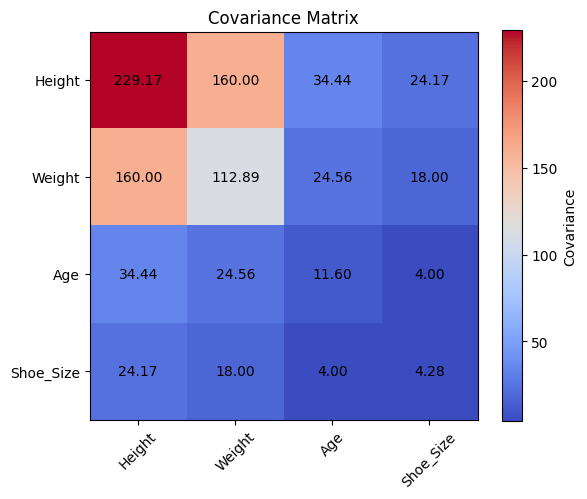

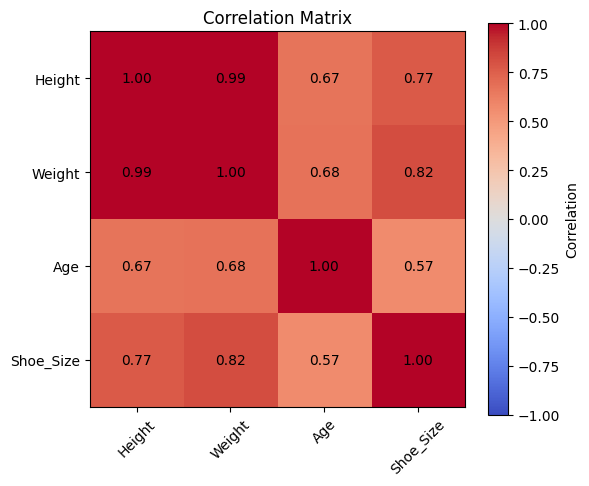

In [34]:
cov_mat = covariance_matrix(X)
print("Covariance Matrix:\n", cov_mat)

corr_mat = correlation_matrix(X)
print("\nCorrelation Matrix:\n", corr_mat)

util_corr_cov.plot_cov(df, cov_mat)
util_corr_cov.plot_corr(df, corr_mat)


---
**Task 5 (medium): Reflection💡📽️**
Reflect on the results. Use the following questions to guide your reflection:
1. Look at your covariance matrix. Which variables have the largest variances? What does that tell you?
2. Which pairs of variables have the highest positive covariance or correlation?
3. Which pairs show negative or near-zero relationships? What might that indicate?
4. Do the results align with what you expected from the dataset?
5. Compare your covariance and correlation matrices:
6. How do the magnitudes of the numbers differ?
7. What stays consistent between them?
8. Why might correlation be a more useful comparison measure when variables are in different units or scales?
9. If two variables have a high covariance but a low correlation, what might that suggest about the scales or units involved?


---

In [ ]:
# 1: height has the highest variance followed by weight - this means that these variables
# # span a wider section of observations numerically (i.e. it is relative to scale)

# 2: Weight and height have a correlation of 0.99, this is super high, as if they were 
# # almost directly constructed linearly together.

# 3: age and shoe size have the lowest correlation. These do not have a relationship

# 4: the observations make sense considering general expectations of this type of data

# 6: covariances are large number relative to the scale of the individual variables.
# # while correlations range in -1 -> 0 -> 1 (with 1 being a total correlation)

# 7: the upper left corner has both the highest variance and correlation pairs.
# # lower covariances also end up being lower in the correlation matrix.

# 8: because they are scaled to a common unit, it is easier to compare different pairs
# # of variables to determine which ones have highest correlation - as covariance is 
# # on the scale of the inputs, they do not directly mean that much when provided as
# # a single numerical measure.

# 9: high covariance and low correlation means that at least one of the variables likely
# # exhibit a high variance, such that when scaled down to the -1 -> 1 scale, the covariance
# # is in fact insignificant.